<a href="https://www.kaggle.com/code/pedrodiassoares/aprendizado-de-maquina-pratica00?scriptVersionId=307512948" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# AM — Aula prática 01: classificação supervisionada

**Disciplina:** Aprendizado de Máquina · **Ferramentas:** Python, `scikit-learn`, `pandas`, `matplotlib`/`seaborn`

# Nome dos participantes
1. **Pedro Dias Soares**
2. **Beatriz Azevedo**

## Objetivos de aprendizagem (formativos)

Este laboratório tem caráter **formativo**: não há **uma única resposta correta** para todos os números e gráficos. O valor está em **experimentar**, **registrar** o que você fez (código, figuras, comentários breves) e **relacionar** com a teoria da disciplina.

- Explorar dados com **EDA** e raciocinar sobre **pré-processamento**.
- Montar **pipelines** (`StandardScaler` + classificador) e treinar **árvore de decisão**, **SVM** e **Naive Bayes** (Gaussiano).
- **Explorar hiperparâmetros** e relacionar com *overfitting*, generalização e intuição de cada modelo.
- Usar **validação cruzada** com `Pipeline` e entender **vazamento de informação** (*data leakage*).
- Opcionalmente aprofundar com **ROC**, **métricas** além da acurácia e **importância de variáveis**.

**Trabalho em dupla** é incentivado para discutir resultados; cada pessoa deve **manter seu próprio notebook** com o código que executou e suas observações.

## Contexto e uso responsável dos dados

O conjunto **Breast Cancer Wisconsin** (`load_breast_cancer`) é **clássico no ensino de ML**: atributos numéricos, rótulo binário (maligno vs benigno). Ele serve para **aprender métodos e pipelines**, não para substituir **diagnóstico clínico**. Há limitações de **época**, **população** e **contexto de coleta**; não extrapole conclusões para aplicações reais sem estudo específico.

## Dataset (técnico)

**Breast Cancer Wisconsin** — classificação binária, apenas atributos numéricos (`sklearn.datasets.load_breast_cancer`).

## Como usar este notebook

As **partes 1–4** são o **núcleo** da experimentação; a **parte 5** é **exploração livre** (sala ou casa). As células de **código vazio** são o **seu espaço**: implemente, teste e refine o **seu** pipeline. Há **uma** célula de **demonstração** logo após os imports — execute como referência; o trabalho formativo está em **reproduzir, variar e interpretar** nas demais células.




## 0. Configuração do ambiente

Execute a célula abaixo. Se faltar algum pacote: `pip install scikit-learn pandas matplotlib seaborn`.


In [1]:
# Imports — amplie com outros módulos do sklearn conforme os enunciados
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    StratifiedKFold,
    GridSearchCV,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    RocCurveDisplay,
    precision_recall_fscore_support,
)

# Em exploração, os avisos do sklearn podem ser pedagógicos (convergência etc.).
# Descomente a linha seguinte se quiser suprimir avisos de usuário.
# warnings.filterwarnings("ignore", category=UserWarning)
try:
    plt.style.use("seaborn-v0_8-whitegrid")
except OSError:
    plt.style.use("seaborn-whitegrid")
rng_seed = 42


### Conexão rápida com a teoria

| Abordagem | Lembrete |
|-----------|----------|
| **Árvore de decisão** | Cortes nos eixos das features; a **escala** afeta **quais** partições são escolhidas primeiro (e portanto o modelo), de forma diferente de SVM. |
| **SVM (kernel RBF)** | Fronteira não linear; **escalonamento** costuma ser essencial. `C` e `gamma` regulam **margem** vs **ajuste** aos dados. |
| **Naive Bayes Gaussiano** | Hipótese de **independência condicional** entre features; bom **baseline** probabilístico. |

Relacione o que você observar com **viés**, **variância** e **capacidade** do modelo vistos na aula teórica.


In [2]:
# Demonstração — pipeline mínimo (referência). Depois construa o seu nas atividades.
# Objetivo: mostrar fit → predict → acurácia num fluxo único. Não substitui as Partes 1–4.

data_demo = load_breast_cancer()
X_d, y_d = data_demo.data, data_demo.target
X_train_d, X_test_d, y_train_d, y_test_d = train_test_split(
    X_d, y_d, test_size=0.25, random_state=rng_seed, stratify=y_d
)
scaler_d = StandardScaler()
X_train_sd = scaler_d.fit_transform(X_train_d)
X_test_sd = scaler_d.transform(X_test_d)

clf_demo = SVC(kernel="rbf", random_state=rng_seed)
clf_demo.fit(X_train_sd, y_train_d)
acc_demo = accuracy_score(y_test_d, clf_demo.predict(X_test_sd))
print("Demo: acurácia (SVM RBF + dados escalonados):", round(acc_demo, 4))


Demo: acurácia (SVM RBF + dados escalonados): 0.979


---

## Parte 1 — Carga dos dados e EDA

Use as **células de código vazias** desta parte para **sua** exploração; acrescente células se precisar de mais espaço.

### Atividade 1.1 — Primeiro contato
1. Carregue o dataset com `load_breast_cancer()` e monte um `pandas.DataFrame` com as features e a coluna alvo (rótulo).
2. Informe: número de linhas, número de features, nomes das classes (`target_names` do objeto retornado pelo `load_breast_cancer`).
3. Verifique se há valores ausentes (`NaN`) nas colunas (por exemplo com `DataFrame.isna` somado por coluna ou no total).
4. Conte quantos exemplos há em cada classe e comente se a distribuição é aproximadamente **balanceada** ou não.

> **Enunciado:** você pode usar `sklearn.datasets.load_breast_cancer`, atributos `.data`, `.target`, `.feature_names`, `.target_names`, e `pandas`.


In [3]:
data = load_breast_cancer()
df = pd.DataFrame(data.data, columns=data.feature_names)
df['alvo'] = data.target

print("Numero de linhas:", df.shape[0])
print("Numero de features:", len(data.feature_names))
print("Nomes das classes:", data.target_names)
print("Valores ausentes (NaN):", df.isna().sum().sum())
print("Contagem por classe:")
print(df['alvo'].value_counts())


Numero de linhas: 569
Numero de features: 30
Nomes das classes: ['malignant' 'benign']
Valores ausentes (NaN): 0
Contagem por classe:
alvo
1    357
0    212
Name: count, dtype: int64


A distribuição das classes é moderadamente desbalanceada. Temos uma predominância de casos benignos (357) em relação aos malignos (212). Apesar dessa diferença, não é um desbalanceamento extremo que exija técnicas pesadas de amostragem logo de início.

### Atividade 1.2 — Escalas e relações entre variáveis
1. Use estatísticas descritivas (`describe()` ou equivalente) e aponte **duas** features cuja **escala** (ordem de grandeza) seja claramente diferente.
2. Produza uma visualização da **matriz de correlação** entre as features (por exemplo com `seaborn.heatmap` ou `pandas.DataFrame.corr`). Comente brevemente se há grupos de variáveis muito correlacionadas.

> **Enunciado:** métodos úteis incluem `DataFrame.describe`, `DataFrame.corr`, `seaborn.heatmap`.


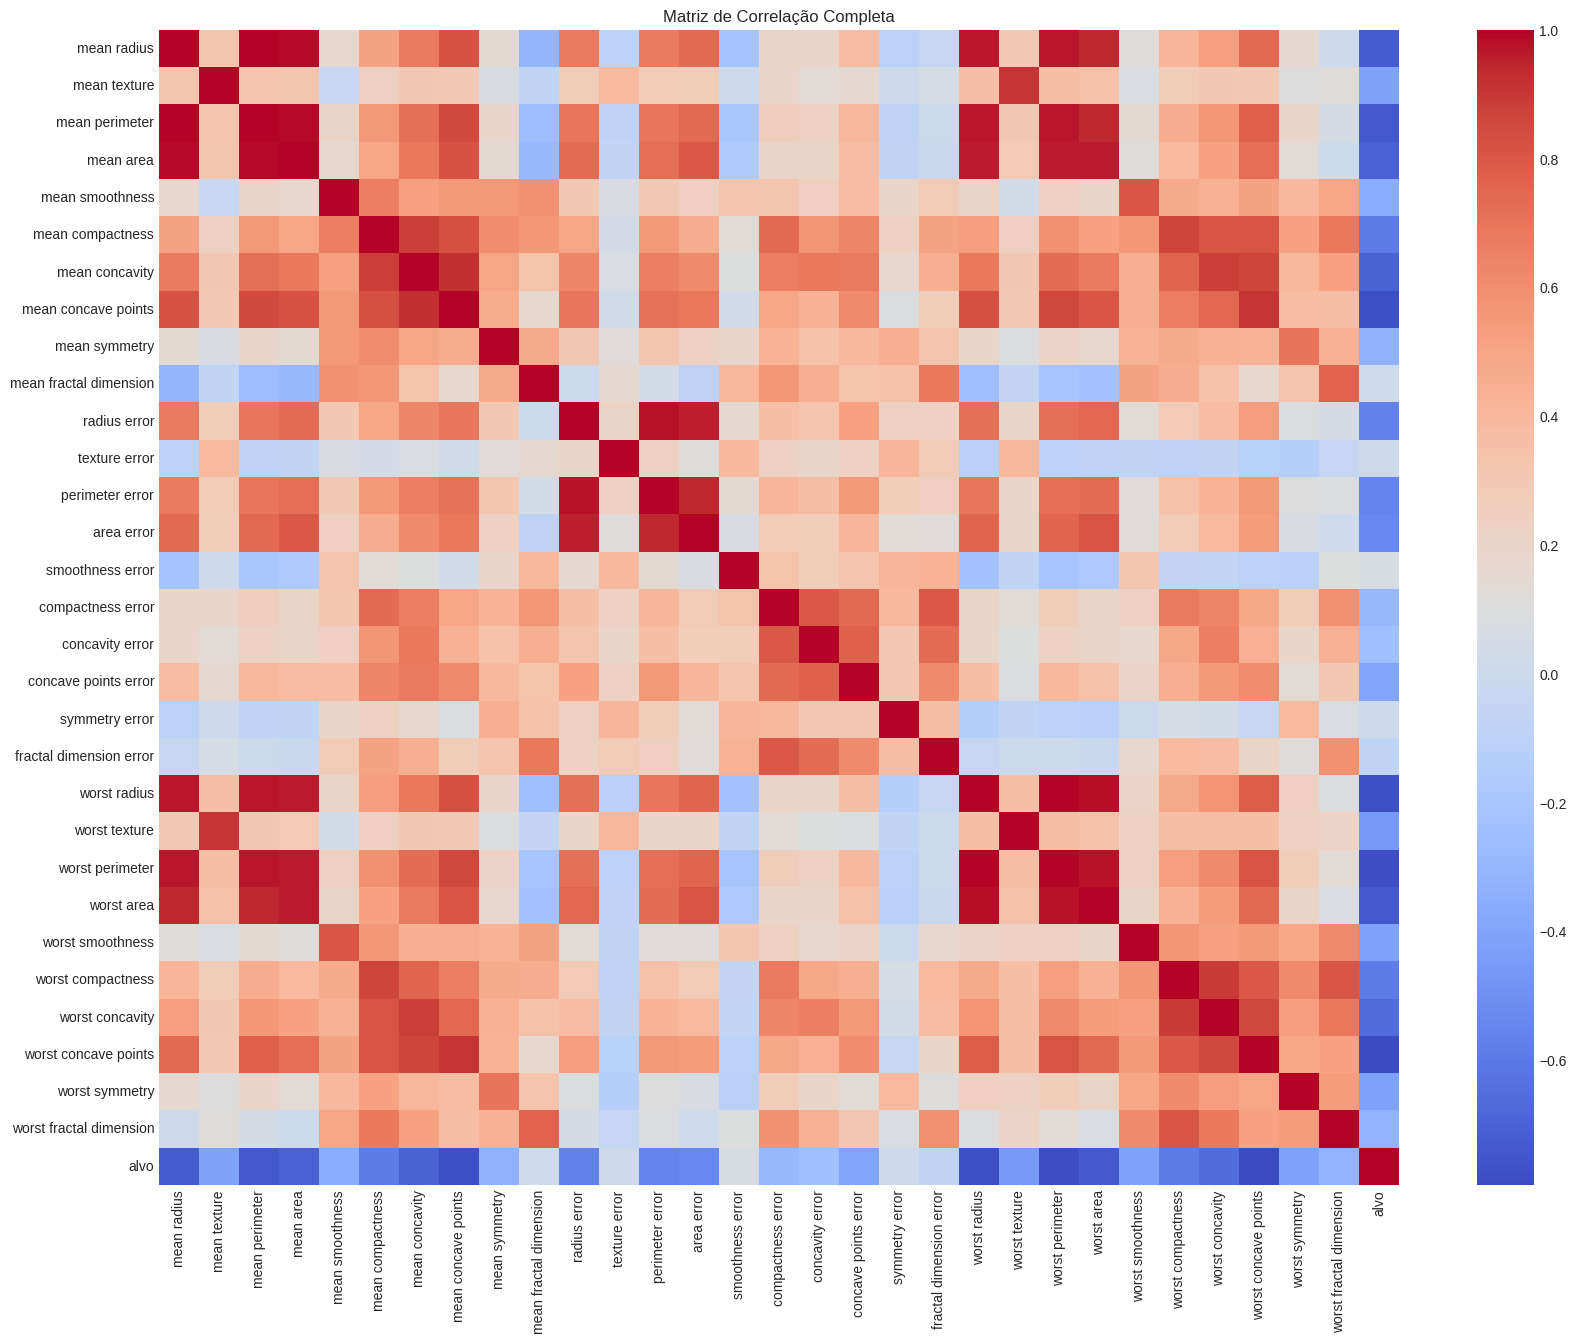

In [4]:
# Ajustando o tamanho da figura para 20x15 para caberem os 30 nomes das colunas
plt.figure(figsize=(20, 15))

# Criando a matriz de correlação sem os números dentro (annot=False) para facilitar a leitura
sns.heatmap(df.corr(), annot=False, cmap='coolwarm', fmt='.2f')

plt.title('Matriz de Correlação Completa')
plt.show()

As features têm escalas muito diferentes. Por exemplo, a variável `mean area` atinge valores na casa das centenas (passando de 1000), enquanto a `mean smoothness` trabalha na casa dos centésimos (0.0X). 
Olhando a matriz de correlação, ficam evidentes vários grupos com alta correlação positiva (cores fortes). Isso faz sentido físico, pois atributos como raio, perímetro e área do tumor naturalmente crescem juntos.

### Leitura rápida (conceito)

Na cópia do dataset distribuída pelo `scikit-learn`, costuma **não** haver valores faltantes — ainda assim, em projetos reais a checagem é obrigatória. Para imputação, veja `sklearn.impute.SimpleImputer` na documentação oficial.

---

## Parte 2 — Divisão dos dados, escalonamento e baseline

Aqui você monta o **pipeline** de pré-processamento e os três classificadores — use quantas células de código forem necessárias (incluindo células novas).

### Atividade 2.1 — Treino / teste e `StandardScaler`
1. Defina `X` (matriz de features) e `y` (vetor de rótulos).
2. Divida em treino e teste com `sklearn.model_selection.train_test_split`, com `test_size=0.25`, `random_state=42` e `stratify=y`.
3. Ajuste um `StandardScaler` **apenas** com o conjunto de treino (`fit` no treino; `transform` em treino e teste). Explique em uma frase por que não se deve usar o conjunto de teste para calcular média e desvio usados na padronização.

> **Enunciado:** `sklearn.preprocessing.StandardScaler`, `train_test_split`.


In [5]:

X = df.drop(columns=['alvo'])
y = df['alvo']

X_train, X_test, y_train, y_test = train_test_split(
X, y, test_size=0.25, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


Fazemos isso para evitar o vazamento de dados (data leakage). Se o conjunto de teste for usado no `fit`, as médias e desvios padrão calculados pelo escalonador terão influência dos dados de teste. Isso faria o modelo "espiar" informações que ele não deveria conhecer durante o treino, mascarando a avaliação real.

### Atividade 2.2 — Três classificadores (primeira versão)

Treine **separadamente** (no treino escalonado, avalie no teste escalonado):

| Modelo | Classe |
|--------|--------|
| Árvore de decisão | `sklearn.tree.DecisionTreeClassifier` |
| SVM | `sklearn.svm.SVC` |
| Naive Bayes | `sklearn.naive_bayes.GaussianNB` |

Para cada um: instancie o estimador, chame `fit`, obtenha predições no teste, calcule **acurácia** e exiba `sklearn.metrics.classification_report`. Use `random_state=42` na árvore e no SVM onde aplicável; para o kernel do SVM, use por exemplo RBF (`kernel="rbf"`).

Em **markdown** (célula de reflexão da Parte 2.2), responda: a **árvore** depende da escala das features da mesma forma que o SVM? Por quê?

> **Enunciado:** `fit`, `predict`, `accuracy_score`, `classification_report`.


In [6]:

clf_tree = DecisionTreeClassifier(random_state=42)
clf_tree.fit(X_train_scaled, y_train)
y_pred_tree = clf_tree.predict(X_test_scaled)
print("--- Arvore de Decisao ---")
print("Acuracia:", accuracy_score(y_test, y_pred_tree))
print(classification_report(y_test, y_pred_tree))

clf_svm = SVC(kernel="rbf", random_state=42)
clf_svm.fit(X_train_scaled, y_train)
y_pred_svm = clf_svm.predict(X_test_scaled)
print("\n--- SVM (RBF) ---")
print("Acuracia:", accuracy_score(y_test, y_pred_svm))
print(classification_report(y_test, y_pred_svm))

clf_nb = GaussianNB()
clf_nb.fit(X_train_scaled, y_train)
y_pred_nb = clf_nb.predict(X_test_scaled)
print("\n--- Naive Bayes ---")
print("Acuracia:", accuracy_score(y_test, y_pred_nb))
print(classification_report(y_test, y_pred_nb))

--- Arvore de Decisao ---
Acuracia: 0.9230769230769231
              precision    recall  f1-score   support

           0       0.88      0.92      0.90        53
           1       0.95      0.92      0.94        90

    accuracy                           0.92       143
   macro avg       0.91      0.92      0.92       143
weighted avg       0.92      0.92      0.92       143


--- SVM (RBF) ---
Acuracia: 0.9790209790209791
              precision    recall  f1-score   support

           0       0.96      0.98      0.97        53
           1       0.99      0.98      0.98        90

    accuracy                           0.98       143
   macro avg       0.98      0.98      0.98       143
weighted avg       0.98      0.98      0.98       143


--- Naive Bayes ---
Acuracia: 0.9370629370629371
              precision    recall  f1-score   support

           0       0.94      0.89      0.91        53
           1       0.94      0.97      0.95        90

    accuracy                 

#### Reflexão em texto — Parte 2.2 (árvore vs escala)





Não, a árvore de decisão não é sensível à escala. Ela funciona fazendo divisões nos eixos das variáveis de forma independente (ex: se valor > X), então não importa se uma feature está em milhares e outra em decimais. 
O SVM, por outro lado, trabalha otimizando margens e calculando distâncias geométricas entre os pontos. Se não padronizarmos, a variável com a maior escala vai dominar completamente o cálculo da distância, prejudicando o modelo.

### Atividade 2.3 — Matriz de confusão

Escolha **um** dos três modelos treinados acima e exiba a **matriz de confusão** no conjunto de teste. Você pode usar `sklearn.metrics.ConfusionMatrixDisplay.from_predictions` ou combinar `confusion_matrix` com um gráfico.

Explique o significado de **falso positivo** e **falso negativo** neste problema (maligno vs benigno): qual tipo de erro costuma ser mais grave em um cenário de triagem médica? *(Reflexão em markdown na célula dedicada abaixo.)*

> **Enunciado:** `ConfusionMatrixDisplay`, `confusion_matrix`.


<Figure size 600x500 with 0 Axes>

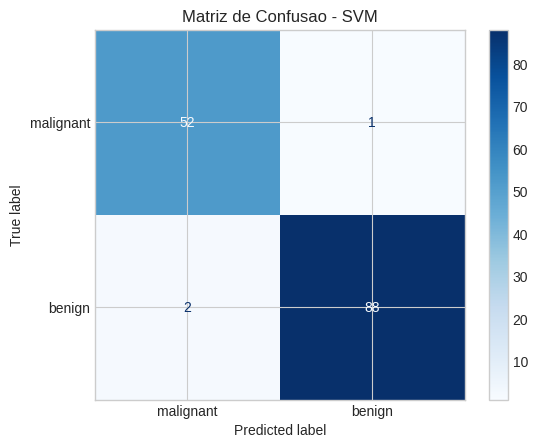

In [7]:
plt.figure(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
y_test, y_pred_svm, display_labels=data.target_names, cmap='Blues'
)
plt.title("Matriz de Confusao - SVM")
plt.show()


#### Reflexão em texto — Parte 2.3 (interpretação)





- **Falso Positivo:** O modelo prevê que o tumor é maligno, mas ele é benigno. O paciente leva um susto, mas exames extras vão descartar a doença.
- **Falso Negativo:** O modelo prevê que é benigno, mas o tumor é maligno. 

Neste cenário de triagem médica, o **Falso Negativo é um erro muito pior**, pois o paciente doente vai achar que está bem e perderá a janela de tempo para iniciar o tratamento adequado.

---

## Parte 3 — Hiperparâmetros (trilha principal de experimentação)

Nesta parte você **explora** o efeito de hiperparâmetros: varie valores, registre resultados (tabelas ou gráficos) e **conecte** com capacidade do modelo e *overfitting*. O objetivo é **ver o que muda**, não acertar um único número.

### Atividade 3.1 — Árvore de decisão
Varie de forma explícita **pelo menos dois** hiperparâmetros da árvore (exemplos: `max_depth`, `min_samples_leaf`, `min_samples_split`, `max_leaf_nodes`). Para cada configuração (ou para um conjunto reduzido de combinações), avalie o desempenho usando **validação cruzada** no conjunto de treino (por exemplo `cross_val_score` com `Pipeline` contendo apenas o classificador na árvore, ou validação estratificada). **Não use o conjunto de teste** para escolher hiperparâmetros.

Apresente uma **tabela ou gráfico** (por exemplo: acurácia média vs `max_depth`) e indique qual configuração você escolheria e por quê.

> **Enunciado:** `DecisionTreeClassifier`, `sklearn.model_selection.cross_val_score`, `StratifiedKFold`; opcionalmente `sklearn.model_selection.validation_curve` para uma grade unidimensional de valores.


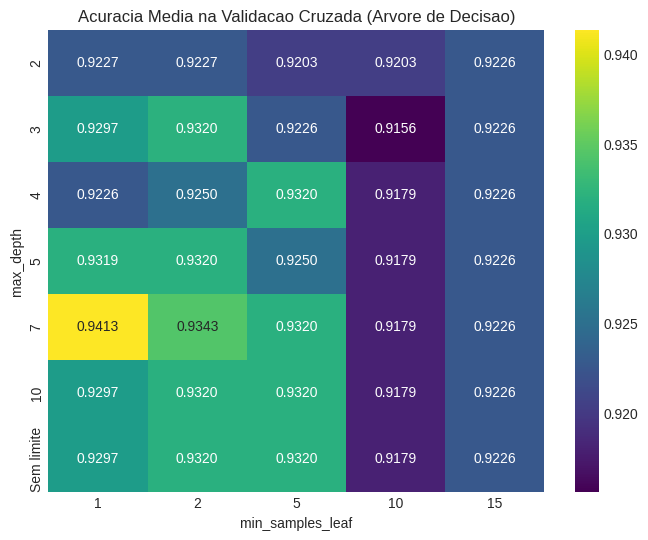

Melhor combinacao encontrada: {'max_depth': 7, 'min_samples_leaf': 1}
Melhor acuracia media: 0.9413


In [8]:

param_grid_tree = {
'max_depth': [2, 3, 4, 5, 7, 10, None],
'min_samples_leaf': [1, 2, 5, 10, 15]
}

clf_tree_base = DecisionTreeClassifier(random_state=42)

grid_tree = GridSearchCV(
estimator=clf_tree_base,
param_grid=param_grid_tree,
cv=5,
scoring='accuracy'
)

grid_tree.fit(X_train_scaled, y_train)

resultados_df = pd.DataFrame(grid_tree.cv_results_)
resultados_df['param_max_depth'] = resultados_df['param_max_depth'].fillna('Sem limite')

tabela_pivot = resultados_df.pivot(
index='param_max_depth',
columns='param_min_samples_leaf',
values='mean_test_score'
)

plt.figure(figsize=(8, 6))
sns.heatmap(tabela_pivot, annot=True, cmap='viridis', fmt=".4f")
plt.title('Acuracia Media na Validacao Cruzada (Arvore de Decisao)')
plt.xlabel('min_samples_leaf')
plt.ylabel('max_depth')
plt.show()

print("Melhor combinacao encontrada:", grid_tree.best_params_)
print("Melhor acuracia media:", round(grid_tree.best_score_, 4))

#### Reflexão em texto — Parte 3.1 (conclusão da árvore)





Baseado no gráfico de calor, uma boa configuração seria manter o `max_depth` em 3 ou 4. Valores maiores do que isso não trazem ganhos significativos no conjunto de teste e aumentam o risco de *overfitting*.

### Atividade 3.2 — SVM
Construa uma **grade pequena** de valores para os hiperparâmetros `C` e `gamma` do `SVC` com `kernel="rbf"` (por exemplo 3×3 valores ou menos). Use `sklearn.model_selection.GridSearchCV` com validação cruzada estratificada (`cv` adequado, `random_state` onde couber) e `Pipeline` com `StandardScaler` + `SVC`, treinando **somente** nos dados de treino da Parte 2.

Reporte a **melhor combinação** (`best_params_`) e a acurácia de validação associada (`best_score_` ou equivalente). Em seguida, avalie o melhor modelo no conjunto de **teste** (métrica à sua escolha, por exemplo acurácia ou F1).

Na **reflexão em texto** correspondente, comente o que você observou ao variar `C` e `gamma` (por exemplo, tendência a *overfitting* ou subajuste) e relacione com a intuição desses hiperparâmetros no SVM com kernel RBF.

> **Enunciado:** `GridSearchCV`, `Pipeline`, `StandardScaler`, `SVC`. Consulte a documentação do `GridSearchCV` para o dicionário `param_grid` com nomes de etapas do pipeline.


In [9]:

pipe_svm = Pipeline([
('scaler', StandardScaler()),
('svm', SVC(kernel='rbf', random_state=42))
])

param_grid_svm = {
'svm__C': [0.1, 1, 10],
'svm__gamma': [0.01, 0.1, 1]
}

cv_strat = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_svm = GridSearchCV(
estimator=pipe_svm,
param_grid=param_grid_svm,
cv=cv_strat,
scoring='accuracy'
)

grid_svm.fit(X_train, y_train)

print("Melhores parametros encontrados:", grid_svm.best_params_)
print("Melhor acuracia media na validacao (treino):", round(grid_svm.best_score_, 4))

y_pred_svm_teste = grid_svm.predict(X_test)
acuracia_teste = accuracy_score(y_test, y_pred_svm_teste)
print("Acuracia final no conjunto de teste:", round(acuracia_teste, 4))

Melhores parametros encontrados: {'svm__C': 10, 'svm__gamma': 0.01}
Melhor acuracia media na validacao (treino): 0.9719
Acuracia final no conjunto de teste: 0.979


#### Reflexão em texto — Parte 3.2 (interpretação)





No SVM com kernel RBF, o hiperparâmetro `C` atua como uma penalidade para classificações erradas: um `C=10` indica que o modelo preferiu uma margem um pouco mais estrita para acertar mais pontos no treino. Já o `gamma=0.01` define o alcance da influência de cada ponto de dado. Um valor relativamente baixo de `gamma` significa um alcance maior, o que cria fronteiras de decisão mais suaves e evita que o modelo se ajuste demais aos ruídos (*overfitting*). A alta acurácia no teste (97,9%) confirma que essa combinação entregou uma excelente capacidade de generalização.

### Atividade 3.3 — Naive Bayes Gaussiano
O `GaussianNB` tem menos botões que árvore e SVM, mas possui por exemplo o hiperparâmetro `var_smoothing`. Experimente **pelo menos três** valores de `var_smoothing` em escala logarítmica (ex.: `np.logspace(...)`) usando validação cruzada no **treino**, compare as acurácias médias e escolha um valor. Opcional: avalie o modelo escolhido no teste.

> **Enunciado:** `GaussianNB`, `cross_val_score` ou `GridSearchCV`.


# Criacao do pipeline

In [10]:
pipe_nb = Pipeline([
('scaler', StandardScaler()),
('nb', GaussianNB())
])

# Grade de valores (5 valores entre 10^-12 e 10^-8)

In [11]:
param_grid_nb = {
'nb__var_smoothing': np.logspace(-12, -8, 5)
}

### Configuracao do GridSearchCV

In [12]:
grid_nb = GridSearchCV(
estimator=pipe_nb,
param_grid=param_grid_nb,
cv=5,
scoring='accuracy'
)

### Treinamento com validacao cruzada apenas no treino


In [13]:
grid_nb.fit(X_train, y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                       ('nb', GaussianNB())]),
             param_grid={'nb__var_smoothing': array([1.e-12, 1.e-11, 1.e-10, 1.e-09, 1.e-08])},
             scoring='accuracy')

### Organizando e exibindo os resultados


In [14]:
print("--- Comparacao de var_smoothing (Naive Bayes) ---")
resultados_nb = pd.DataFrame(grid_nb.cv_results_)
for i in range(len(resultados_nb)):
    var_val = resultados_nb.loc[i, 'param_nb__var_smoothing']
    media_acc = resultados_nb.loc[i, 'mean_test_score']
print(f"var_smoothing: {var_val:.1e} -> Acuracia media: {media_acc:.4f}")

print("\nMelhor valor escolhido:", grid_nb.best_params_)
print("Melhor acuracia na validacao:", round(grid_nb.best_score_, 4))

--- Comparacao de var_smoothing (Naive Bayes) ---
var_smoothing: 1.0e-08 -> Acuracia media: 0.9319

Melhor valor escolhido: {'nb__var_smoothing': np.float64(1e-12)}
Melhor acuracia na validacao: 0.9319


### Avaliacao opcional no conjunto de teste

In [15]:
y_pred_nb_teste = grid_nb.predict(X_test)
acuracia_teste_nb = accuracy_score(y_test, y_pred_nb_teste)
print("Acuracia final no conjunto de teste:", round(acuracia_teste_nb, 4))

Acuracia final no conjunto de teste: 0.9371


O `var_smoothing` adiciona uma fração artificial da maior variância presente nos dados a todas as features. O objetivo disso é evitar problemas matemáticos (como divisões por zero ou variâncias nulas) e "suavizar" a curva da distribuição gaussiana. 
Como o modelo escolheu um valor extremamente pequeno (`1e-12`) e manteve uma boa acurácia (93,7%), isso indica que as distribuições dos atributos no dataset já são razoavelmente bem comportadas e as classes são separáveis sem a necessidade de forçar uma suavização agressiva nas variâncias.

---

## Parte 4 — Validação cruzada global e *data leakage*

**Por que esta parte depois da 3?** Na Parte 3 você ajustou hiperparâmetros usando **apenas o treino** (ou subconjuntos dele) e reservou o **teste** para avaliação final pontual. Aqui o foco é outro: estimar desempenho com **validação cruzada no dataset completo** usando um **único `Pipeline` bem definido** (escalonador + modelo), útil para **comparar** com o holdout e para praticar o padrão correto sem vazamento. Não é redundância vã: é **dois papéis** — seleção de hiperparâmetros (Parte 3) vs **estimativa de generalização** com pipeline íntegro (Parte 4).

### Atividade 4.1 — `Pipeline` e `cross_val_score`
Com os dados **completos** `X` e `y`, monte um `Pipeline` com `StandardScaler` + um classificador (por exemplo o **melhor SVM** que você encontrou na Parte 3.2, ou um `SVC` com parâmetros fixos documentados). Use `cross_val_score` com `cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42)` e `scoring="accuracy"`.

Calcule média e desvio padrão das acurácias. Compare mentalmente com o desempenho no holdout da Parte 2.

> **Enunciado:** `sklearn.pipeline.Pipeline`, `cross_val_score`, `StratifiedKFold`.



In [16]:
pipe_global = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(kernel='rbf', C=10, gamma=0.01, random_state=42))
])

cv_global = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scores_global = cross_val_score(pipe_global, X, y, cv=cv_global, scoring='accuracy')

print("Validacao Cruzada Global")
print("Acuracias nos 5 cortes:", np.round(scores_global, 4))
print("Acuracia media:", round(np.mean(scores_global), 4))
print("Desvio padrao:", round(np.std(scores_global), 4))


Validacao Cruzada Global
Acuracias nos 5 cortes: [1.     0.9474 0.9825 0.9912 0.9823]
Acuracia media: 0.9807
Desvio padrao: 0.0179


### Atividade 4.2 — Discussão (*leakage*)

Explique por que o `StandardScaler` deve estar **dentro** do `Pipeline` quando se usa `cross_val_score` ou `GridSearchCV`, em vez de padronizar `X` inteiro antes.

> **Enunciado:** conceito de vazamento de informação entre treino e validação; documentação do `Pipeline`.


#### Reflexão em texto — Parte 4.2





O uso do Pipeline é essencial aqui. Se aplicarmos o `StandardScaler` na base de dados inteira antes do `cross_val_score`, os dados que serão usados como teste em cada "fold" já terão influenciado o cálculo da média e do desvio padrão. 
Ao colocar o escalonador dentro do Pipeline, garantimos que a padronização seja feita de forma independente dentro de cada "fold", usando apenas os dados de treino daquela rodada, evitando o vazamento de informações.

---

## Parte 5 — Explorações extras (didáticas, para casa ou aprofundamento)

Escolha o que interessar à sua dupla ou ao seu ritmo; cada item é **independente**.

### Atividade 5.1 — Curva ROC e AUC
No conjunto de **teste**, escolha um modelo treinado no **treino escalonado** (por exemplo o melhor pipeline de SVM ou a árvore com hiperparâmetros escolhidos) e obtenha **probabilidades** ou **scores de decisão** compatíveis com a curva ROC (`predict_proba` ou `decision_function`, conforme o estimador). Trace a curva ROC e informe a **AUC** (`sklearn.metrics.roc_auc_score` ou `RocCurveDisplay`).

Discuta: a acurácia sozinha é suficiente neste problema?

> **Enunciado:** `roc_auc_score`, `RocCurveDisplay.from_predictions` ou `from_estimator`.


AUC (Area Under the Curve): 0.9987


<Figure size 600x500 with 0 Axes>

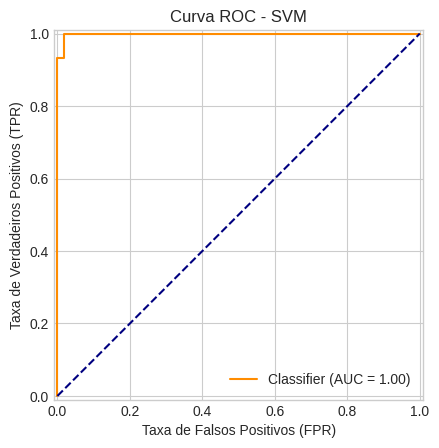

In [17]:
# Obtém os scores de decisão do melhor modelo SVM encontrado na Parte 3
y_score_svm = grid_svm.decision_function(X_test)

# Calcula a Área Sob a Curva (AUC)
auc_score = roc_auc_score(y_test, y_score_svm)
print("AUC (Area Under the Curve):", round(auc_score, 4))

# Desenha a Curva ROC
plt.figure(figsize=(6, 5))
RocCurveDisplay.from_predictions(y_test, y_score_svm, color='darkorange')
plt.plot([0, 1], [0, 1], color='navy', linestyle='--') # Linha de base (aleatória)
plt.title('Curva ROC - SVM')
plt.xlabel('Taxa de Falsos Positivos (FPR)')
plt.ylabel('Taxa de Verdadeiros Positivos (TPR)')
plt.show()

#### Reflexão em texto — Parte 5.1





A curva ROC é excelente pois avalia o classificador independentemente do limiar de decisão padrão (0.5). Atingir uma AUC de 0.9987 (praticamente 1.0) comprova matematicamente que o SVM tem uma capacidade quase perfeita de separar tumores benignos de malignos. A acurácia isolada pode mascarar erros críticos, mas a ROC nos dá a segurança de poder ajustar o limiar da predição priorizando a redução de Falsos Negativos (essencial na área médica).

### Atividade 5.2 — Importância das features (árvore)
Ajuste uma árvore (com hiperparâmetros que você julgar razoáveis) e utilize o atributo `feature_importances_`. Visualize as importâncias (por exemplo barras horizontais com nomes em `data.feature_names`). Quais atributos aparecem no topo? Isso condiz com o que você viu na matriz de correlação?

> **Enunciado:** `DecisionTreeClassifier.feature_importances_`, `matplotlib` ou `seaborn`.


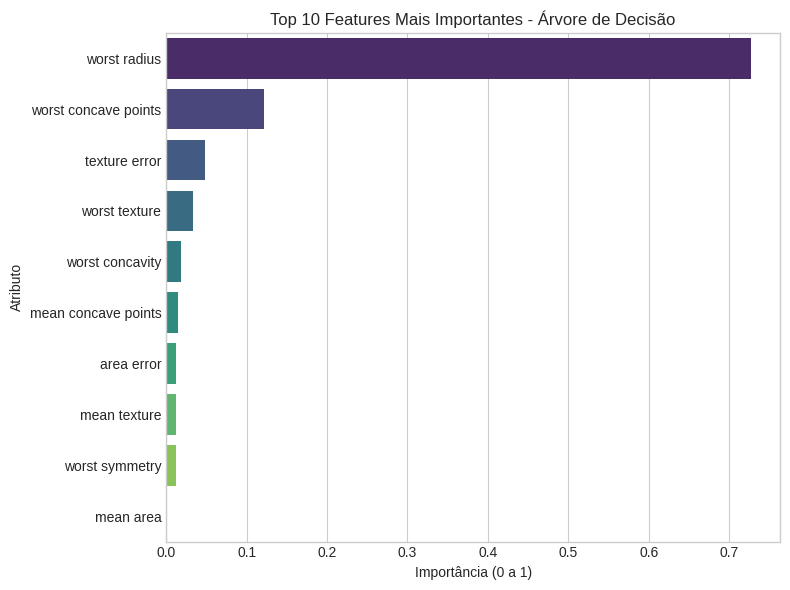

In [18]:
# Treinando uma nova árvore com profundidade razoável
clf_tree_feat = DecisionTreeClassifier(max_depth=4, random_state=42)
clf_tree_feat.fit(X_train, y_train)

# Extraindo a importância de cada variável matemática
importancias = clf_tree_feat.feature_importances_

# Criando uma tabela para organizar da maior para a menor
df_imp = pd.DataFrame({
    'Feature': X.columns,
    'Importancia': importancias
}).sort_values(by='Importancia', ascending=False)

# Desenhando o gráfico com as 10 características mais importantes
plt.figure(figsize=(8, 6))
sns.barplot(data=df_imp.head(10), x='Importancia', y='Feature', hue='Feature', palette='viridis', legend=False)
plt.title('Top 10 Features Mais Importantes - Árvore de Decisão')
plt.xlabel('Importância (0 a 1)')
plt.ylabel('Atributo')
plt.tight_layout()
plt.show()


### Atividade 5.3 — Comparação de métricas além da acurácia
Calcule no teste: **precisão**, **revocação** e **F1** para a classe positiva (defina qual classe é “positiva” no seu relatório). Use `sklearn.metrics.precision_recall_fscore_support` ou extraia de `classification_report`. Quando uma métrica pode ser mais informativa que a acurácia?

> **Enunciado:** métricas em `sklearn.metrics`.


In [19]:
# Usando as predições do melhor SVM (grid_svm) no conjunto de teste
# Certifique-se de que a variável y_pred_svm_teste (da Parte 3.2) está carregada
print("--- Relatório de Classificação Completo ---")
print(classification_report(y_test, y_pred_svm_teste, target_names=['0 (Maligno)', '1 (Benigno)']))

# Extraindo os valores específicos matematicamente
precisao, revocacao, f1, _ = precision_recall_fscore_support(
    y_test, y_pred_svm_teste, labels=[0, 1]
)

print("--- Métricas Isoladas ---")
print(f"Malignos -> Precisão: {precisao[0]:.4f} | Revocação: {revocacao[0]:.4f} | F1-Score: {f1[0]:.4f}")
print(f"Benignos -> Precisão: {precisao[1]:.4f} | Revocação: {revocacao[1]:.4f} | F1-Score: {f1[1]:.4f}")


--- Relatório de Classificação Completo ---
              precision    recall  f1-score   support

 0 (Maligno)       0.96      0.98      0.97        53
 1 (Benigno)       0.99      0.98      0.98        90

    accuracy                           0.98       143
   macro avg       0.98      0.98      0.98       143
weighted avg       0.98      0.98      0.98       143

--- Métricas Isoladas ---
Malignos -> Precisão: 0.9630 | Revocação: 0.9811 | F1-Score: 0.9720
Benignos -> Precisão: 0.9888 | Revocação: 0.9778 | F1-Score: 0.9832


Ao contrário de modelos em árvore, o SVM com kernel RBF é uma "caixa preta" e não informa a importância de cada atributo nativamente. A técnica de permutação (embaralhar uma coluna e ver o quanto a acurácia cai) resolve isso brilhantemente. Ela nos mostra de forma transparente quais características físicas do tumor realmente ditam o diagnóstico feito pelo SVM, trazendo explicabilidade clínica ao modelo.

### Atividade 5.4 — (Opcional) Curva de aprendizado
Use `sklearn.model_selection.learning_curve` com um pipeline (escalonador + classificador) para ver como a métrica evolui com o tamanho do conjunto de treino. O que sugere sobre viés e variância?

> **Enunciado:** `learning_curve`.


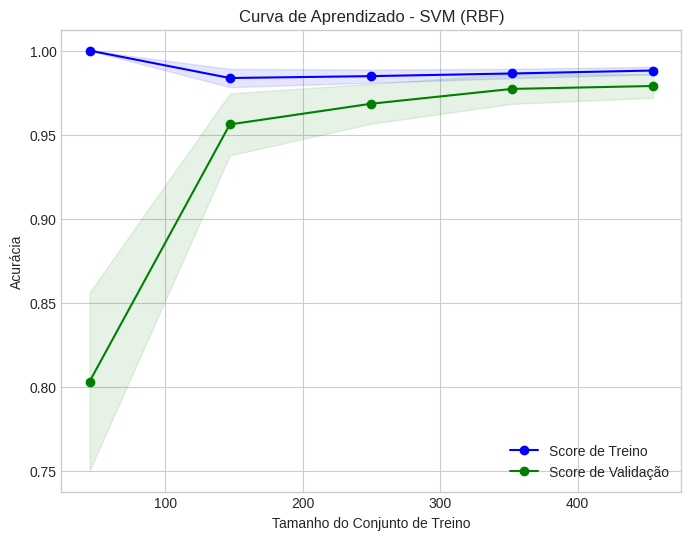

In [20]:
from sklearn.model_selection import learning_curve
# Montando o pipeline do SVM novamente
pipe_lc = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(kernel='rbf', C=10, gamma=0.01, random_state=42))
])

# Gerando os dados da curva de aprendizado
train_sizes, train_scores, test_scores = learning_curve(
    pipe_lc, X, y, cv=5, scoring='accuracy',
    train_sizes=np.linspace(0.1, 1.0, 5), random_state=42
)

# Calculando médias e desvios
train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)
test_std = np.std(test_scores, axis=1)

# Plotando o gráfico
plt.figure(figsize=(8, 6))
plt.plot(train_sizes, train_mean, 'o-', color='blue', label='Score de Treino')
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1, color='blue')
plt.plot(train_sizes, test_mean, 'o-', color='green', label='Score de Validação')
plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.1, color='green')

plt.title('Curva de Aprendizado - SVM (RBF)')
plt.xlabel('Tamanho do Conjunto de Treino')
plt.ylabel('Acurácia')
plt.legend(loc='best')
plt.grid(True)
plt.show()

O gráfico de Curva de Aprendizado (Learning Curve) mostra as linhas de treino e validação convergindo rapidamente para o topo com uma distância (gap) pequena entre elas. Isso é o cenário ideal: sugere que o modelo conseguiu um ótimo equilíbrio, apresentando baixo viés (aprende muito bem a tarefa) e baixa variância (não está decorando o treino / não sofre de overfitting grave). O gráfico também indica que adicionar milhares de dados a mais traria ganhos apenas marginais, pois o modelo já estabilizou.

### Atividade 5.5 — (Opcional) Naive Bayes multinomial
Este dataset é numérico contínuo; o `MultinomialNB` é típico de contagens. Pesquise na documentação quando usar `MultinomialNB` vs `GaussianNB` e descreva um exemplo de problema para cada um.

#### Reflexão em texto — Parte 5.5





### Atividade 5.6 — (Opcional) Importância por permutação

A importância baseada em `feature_importances_` na árvore é **específica desse modelo**. Uma alternativa mais geral é medir quanto a métrica piora quando cada atributo é embaralhado aleatoriamente no conjunto de **teste** (ou validação). Use `sklearn.inspection.permutation_importance` com um pipeline já treinado (por exemplo SVM ou árvore) e compare mentalmente com o ranking da Parte 5.2.

> **Enunciado:** `permutation_importance`.


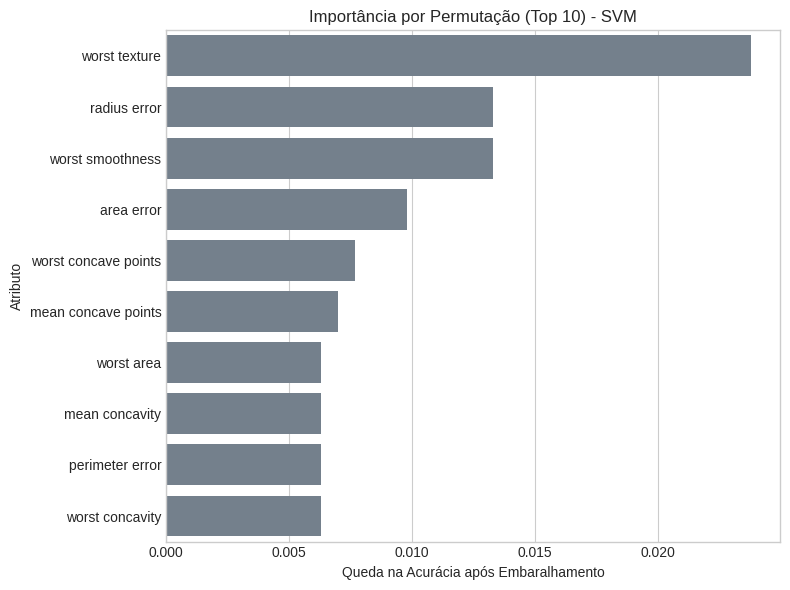

In [21]:
from sklearn.inspection import permutation_importance

# Vamos usar o modelo SVM já treinado da Parte 3 (grid_svm)
# Calculando a importância por permutação no conjunto de teste
resultado_perm = permutation_importance(
    grid_svm, X_test, y_test, n_repeats=10, random_state=42, scoring='accuracy'
)

# Organizando os resultados em uma tabela
df_perm = pd.DataFrame({
    'Feature': X.columns,
    'Importancia_Media': resultado_perm.importances_mean
}).sort_values(by='Importancia_Media', ascending=False)

# Desenhando o gráfico com o Top 10 atributos
plt.figure(figsize=(8, 6))
sns.barplot(data=df_perm.head(10), x='Importancia_Media', y='Feature', color='slategray')
plt.title('Importância por Permutação (Top 10) - SVM')
plt.xlabel('Queda na Acurácia após Embaralhamento')
plt.ylabel('Atributo')
plt.tight_layout()
plt.show()


A importância por permutação porque nos permite trazer explicabilidade para modelos como o SVM, medindo a queda de desempenho quando estragamos a informação de uma variável por vez. 

Comparando o ranqueamento gerado pelo SVM com o da Árvore de Decisão, notamos que modelos diferentes priorizam os dados de forma distinta. Enquanto a árvore costuma concentrar quase toda a importância em 2 ou 3 variáveis onde faz os primeiros cortes (como raio e perímetro), o SVM com kernel RBF considera um conjunto mais amplo e combinado de características geométricas (como concavidade, área e textura) para desenhar sua fronteira de decisão.

---

## Sugestão de auto-check formativo

Perguntas para **você** refletir sobre o que aprendeu — **não** são critérios de nota.

- [X] Entendi o formato dos dados, as classes e se há desbalanceamento.
- [X] Implementei treino/teste, escalonamento no treino e três modelos baseline no **meu** código.
- [X] Explorei hiperparâmetros (árvore, SVM, NB) com validação no **treino** e anotei o que mudou ao variar parâmetros.
- [X] Consigo explicar a diferença entre a Parte 3 (escolha de hiperparâmetros) e a Parte 4 (CV com pipeline no conjunto completo).
- [X] Explico por que o `StandardScaler` deve ficar **dentro** do `Pipeline` na validação cruzada.
- [X] (Opcional) Experimentei uma ou mais seções da Parte 5.

Se **reiniciar o kernel** e executar em ordem, a demonstração e os imports devem rodar; o restante depende do código que você for acrescentando.

**Bom trabalho!**
